# Лабораторная работа #2 #
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

### Исходные данные  ####
Исследуемая функция: $ f(x) = 1.826 * (sin^3(x) + cos^2(x) - 0.5sin(2x)) $
Промежуток: $ [0, 8] $

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import math

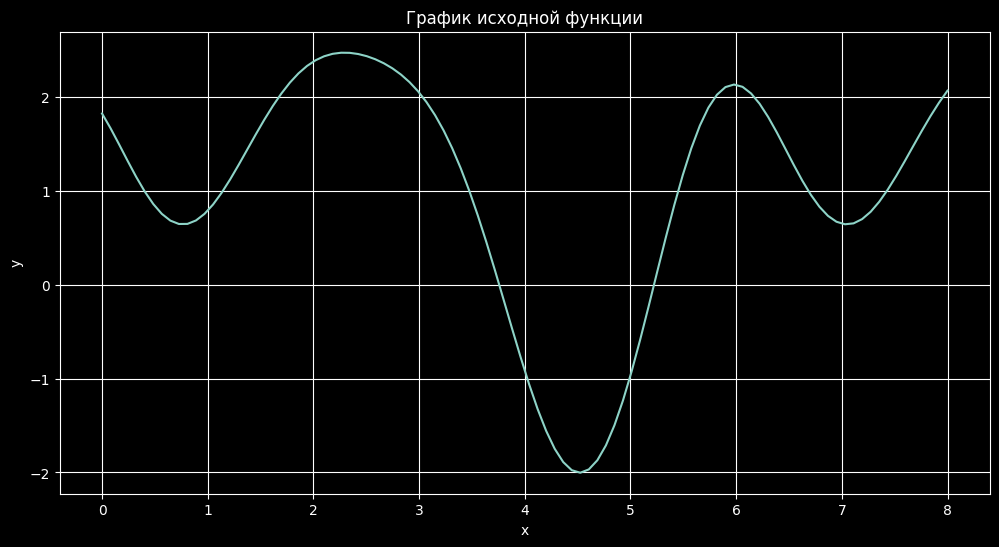

In [64]:
# График исходной функции
a = 0
b = 8
epsilon = 0.001
x = np.linspace(a, b, 100)  # 100 точек от -10 до 10
y = 1.826 * (np.sin(x) ** 3 + np.cos(x) ** 2 - 0.5 * np.sin(2 * x))

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('График исходной функции')
plt.grid(True)
plt.show()

По графику можно заметить 5 точек экстремума:
1. На промежутке [0, 1] (минимум)
2. На промежутке [2, 3] (максимум)
3. На промежутке [4, 5] (максимум)
4. На промежутке [5, 7] (максимум)
5. На промежутке [6, 8] (максимум)

## I. Прямые методы минимизации (0-го порядка)
\- методы, использующие только значения функции и не требующие вычисления ее производных

*Для дальнейшего выполнения введем программный метод, реализующий нашу функцию*

In [65]:
def func(x: float) -> float:
    return 1.826 * (math.sin(x) ** 3 + math.cos(x) ** 2 - 0.5 * math.sin(2 * x))

### Метод половинного деления

#### 1. Рассчитаем две точки x1 и x2 вблизи центра промежутка: ####

$$ \displaystyle x_1 = \frac{a + b - \varepsilon}{2} $$
$$ \displaystyle x_2 = \frac{a + b + \varepsilon}{2} $$

Будем работать с промежутком [4,5], посчитаем значение точек программно:


In [66]:
a = 4
b = 5


def define_x(a, b, epsilon, positive: bool):
    if positive:
        return (a + b + epsilon) / 2
    else:
        return (a + b - epsilon) / 2


x1 = define_x(a, b, epsilon, positive=False)
x2 = define_x(a, b, epsilon, positive=True)

print(f'''Значение точек:
х1: {x1}
х2: {x2}
''')

Значение точек:
х1: 4.4995
х2: 4.5005



#### 2. Посчитаем значения для y1 и y2 функции

$$
y_1 = f(x_1)
$$

$$
y_2 = f(x_2)
$$

In [67]:
y1 = func(x1)
y2 = func(x2)

print(f'''
Значения функции в точках x1, x2:

f(x1) = y1 = {y1}
f(x2) = y2 = {y2}
''')


Значения функции в точках x1, x2:

f(x1) = y1 = -2.0006838922792607
f(x2) = y2 = -2.0008761253051417



#### 3-4. Сравним значения $y_1$ и $y_2$ и длину интервала $(b - a)$ с $2 \varepsilon $

Если $ y_1 > y_2 \implies a = x_1 $
Если $ y_2 > y_1 \implies b = x_2 $


In [68]:
def compare_y(x1, x2, y1, y2, a, b):
    if y1 > y2:
        return x1, b
    else:
        return a, x2

Если $ (b - a) < 2\varepsilon $, то повторяем п.1-3

Иначе идем на п.5

In [69]:
def is_epsilon_hitting(a, b, epsilon):
    if (b - a) < (2 * epsilon):
        return True
    else:
        return False

In [70]:
a = 4
b = 5


def half_division_method(a, b, epsilon):
    iteration = 0

    while True:
        iteration += 1

        x1 = define_x(a, b, epsilon, False)
        x2 = define_x(a, b, epsilon, True)

        y1 = func(x1)
        y2 = func(x2)
        a, b = compare_y(x1, x2, y1, y2, a, b)

        if is_epsilon_hitting(a, b, epsilon) or iteration == 50:
            return iteration, a, b, b - a


iter, res_a, res_b, delta = half_division_method(a, b, epsilon)

print(f'''
Iter: {iter}
a: {res_a}
b: {res_b}
delta: {delta}
''')


Iter: 10
a: 4.519011718750001
b: 4.520987304687501
delta: 0.001975585937500135



#### 5. Вычисляем xm

$$
xm = \frac{a + b}{2}
$$

$$
ym = f(xm)
$$

In [71]:
def define_result(a, b):
    xm = (a + b) / 2
    ym = func(xm)

    return xm, ym
xm, ym = define_result(res_a, res_b)
print(f'''
Результаты вычислений:

xm = {xm}
ym = {ym}
''')


Результаты вычислений:

xm = 4.519999511718751
ym = -2.0027261749298844



### Метод золотого сечения ###

#### 1. Вычислим начальные точки $ x1 $ и $ x2 $ по формулам:

$$ x1 = a + 0,382 \times (b - a) $$
$$ x2 = a + 0,618 \times (b - a) $$

Затем вычисляются значение функции в этих точках.

<br>

#### 2. Оценим значения функций в начальных точках:

\- Если $ f(x1) < f(x2) $, то оставляем отрезок $[а, x2]$. На второй итерации $x2$ полагаем равным $x1$, а $x1$ вычисляем по формуле:
$$ x1 = a + 0,382 \times (x2 - a) $$
Значение функции вычисляется только в точке $x1$, так как значение функции в $x2$ уже было вычислено на предыдущем шаге.
### ###
\- Если $ f(x1) ≥ f(x2) $, то оставляем отрезок $[x1, b]$. На второй итерации $x1$ полагаем равным $x2$, а $x2$ вычисляем по формуле:
$$ x2 = a + 0,618 \times (b - x1) $$
Значение функции вычисляется только в точке $x2$, так как значение функции в $x1$ уже было вычислено на предыдущем шаге.

<br>

#### 3. Вычисления продолжают до тех пор, пока длина интервала не станет меньше требуемой точности.


Реализация функции минимизации методом золотого сечения:

In [72]:
def golden_slice(a, b, x1, x2, eps = 0.01):
    if ((b - a) < eps):
        return (a + b) / 2

    if (x1 is None and x2 is None):
        x1 = a + 0.382 * (b - a)
        x2 = a + 0.618 * (b - a)
    elif (x1 is None):
        x1 = a + 0.382 * (x2 - a)
    elif (x2 is None):
        x2 = a + 0.618 * (b - x1)

    y1 = func(x1)
    y2 = func(x2)

    if (y1 < y2):
        return golden_slice(a, x2, None, x1, eps)
    else:
        return golden_slice(x1, b, x2, None, eps)

xMin = golden_slice(4, 5, None, None)

print(f'Точка минимума: {xMin:.6f}')
print(f'Значение функции в точке: {func(xMin):.6f}')

Точка минимума: 4.521286
Значение функции в точке: -2.002721


## II. Методы минимизации 1-го порядка
\- методы, использующие информацию о первой производной целевой функции

*Для дальнейшего выполнения введем программный метод, реализующий нашу функцию*

In [73]:
def func_prime(x):
    return 1.826 * (3 * np.sin(x)**2 * np.cos(x) - 2 * np.cos(x) * np.sin(x) - np.cos(2*x))

### Метод хорд

#### Теория ####

Равенство $f’(x) = 0$ является необходимым и достаточным условием глобального минимума выпуклой дифференцируемой функции $f(x)$.
Если на концах отрезка $[a, b]$ производная $f’(x)$ имеет разные знаки, т.е. $𝑓′(𝑎) ∙ 𝑓′(𝑏) < 0$, и она непрерывна, то на интервале $(a, b)$ найдется точка, в которой $f’(x)$ обращается в нуль. В этом случае поиск точки минимума на отрезке эквивалентен решению уравнения $𝑓′(𝑥) = 0 $, $ 𝑥 ∈ (𝑎, 𝑏) $

Таким образом, при 𝑓′(𝑎) ∙ 𝑓′(𝑏) < 0, любой приближенный метод решения уравнения (20) можно рассматривать как метод минимизации выпуклой непрерывно дифференцируемой функции f(x) на отрезке $[a, b]$.

Сущность приближенного решения уравнения F(x)=0 на отрезке $[a, b]$ при F a ∙ F b < 0 методом хорд состоит в исключении отрезков путем определения $ \tilde{x} $ - точки пересечения с осью OX хорды графика функции $ F(x) $ на отрезке $ [a, b] $

#### Алгоритм ####

#### 1. Найти значение функции в точке пересечения с осью $Ox$ хорды графика функции F(x) на отрезке $ [a, b] $ ####
Найти $ \tilde{x} $ по формуле:
$$ \tilde{x} = a - \frac{f'(a)}{f'(a) - f'(b)} \times (a - b) $$
Вычислить $𝑓′(\tilde{x})$ и перейти к п2.

#### 2. Проверка на окончание поиска ####
Если 𝑓′(𝑥^) ≤ 𝜀, то положить 𝑥* = \tilde{x}, 𝑓* = 𝑓(\tilde{x}), и завершить поиск, иначе перейти к п3.

#### 3. Переход к новому отрезку.
Если 𝑓′(𝑥^) > 0, то положить b = x^, 𝑓′(𝑏) = 𝑓′(x^), иначе положить a = \tilde{x}, f′(𝑎) = 𝑓′(𝑥^). Перейти к п1.


_Реализация функции метода хорд:_

In [74]:
def chord_method(f_prime, a, b, eps=0.001, max_iter=100):
    """
    Метод хорд для поиска минимума функции (решения уравнения f'(x) = 0)

    Параметры:
    f_prime - производная целевой функции
    a, b - границы интервала [a, b], содержащего точку минимума
    eps - требуемая точность (для |f'(x)|)
    max_iter - максимальное число итераций

    Возвращает:
    x_star - приближение к точке минимума
    """

    # Проверка знаков производной на концах интервала
    f_prime_a = f_prime(a)
    f_prime_b = f_prime(b)

    if f_prime_a * f_prime_b >= 0:
        raise ValueError("Производная должна иметь разные знаки на концах интервала")

    iter_count = 0

    for _ in range(max_iter):
        iter_count += 1

        # Вычисление точки пересечения хорды с осью OX (формула 21)
        x_hat = a - f_prime_a * (a - b) / (f_prime_a - f_prime_b)
        f_prime_x = f_prime(x_hat)

        # Проверка условия остановки
        if abs(f_prime_x) <= eps:
            return x_hat

        # Переход к новому отрезку (шаг 3 алгоритма)
        if f_prime_x > 0:
            b = x_hat
            f_prime_b = f_prime_x
        else:
            a = x_hat
            f_prime_a = f_prime_x

    # Если достигнуто максимальное число итераций
    x_final = (a + b) / 2
    return x_final


minimum = chord_method(func_prime, 4, 5)
print(f"Минимум в точке x = {minimum:.6f}")
print(f"f({minimum:.3f}) = {func(minimum):.6f}")

Минимум в точке x = 4.520163
f(4.520) = -2.002726
